In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
model_data = pd.read_csv("../data/cleaned/feature_engineered.csv")
model_data["Date"] = pd.to_datetime(model_data["Date"])

In [3]:
model_data = model_data.sort_values(
    ["SKU", "Date"]
).reset_index(drop=True)

In [4]:
baseline_data = model_data.dropna(
    subset=["Lag_1"]
).copy()

In [5]:
print("Original rows:", len(model_data))
print("Baseline rows:", len(baseline_data))

Original rows: 36550
Baseline rows: 36500


In [6]:
train = baseline_data[
    baseline_data["Date"] < "2025-01-01"
].copy()

test = baseline_data[
    baseline_data["Date"] >= "2025-01-01"
].copy()

In [7]:
print("Training:", train.shape)
print("Testing :", test.shape)

Training: (18250, 52)
Testing : (18250, 52)


In [8]:
print("Training dates:",
      train["Date"].min(),
      "to",
      train["Date"].max())

print("Testing dates:",
      test["Date"].min(),
      "to",
      test["Date"].max())

Training dates: 2024-01-02 00:00:00 to 2024-12-31 00:00:00
Testing dates: 2025-01-01 00:00:00 to 2025-12-31 00:00:00


In [9]:
y_actual = test["Units_Sold"]
y_pred_baseline = test["Lag_1"]

In [10]:
mae = mean_absolute_error(
    y_actual,
    y_pred_baseline
)

print("Baseline MAE:", mae)

Baseline MAE: 4.280767123287672


In [11]:
rmse = np.sqrt(
    mean_squared_error(
        y_actual,
        y_pred_baseline
    )
)

print("Baseline RMSE:", rmse)

Baseline RMSE: 5.6786743581361865


In [12]:
mape_data = test[test["Units_Sold"] != 0].copy()

mape = (
    np.mean(
        np.abs(
            (mape_data["Units_Sold"] - mape_data["Lag_1"])
            / mape_data["Units_Sold"]
        )
    ) * 100
)

print("Baseline MAPE:", mape, "%")

Baseline MAPE: 42.42080764944139 %


In [13]:
baseline_results = pd.DataFrame({
    "Model": ["Naive Baseline"],
    "MAE": [mae],
    "RMSE": [rmse],
    "MAPE": [mape]
})

baseline_results

,Model,MAE,RMSE,MAPE
0,Naive Baseline,4.280767,5.678674,42.420808


In [14]:
comparison = test[
    ["Date", "SKU", "Units_Sold", "Lag_1"]
].copy()

comparison["Prediction"] = comparison["Lag_1"]

comparison.head(20)

,Date,SKU,Units_Sold,Lag_1,Prediction
366,2025-01-01,SKU001,10,8.0,8.0
367,2025-01-02,SKU001,11,10.0,10.0
368,2025-01-03,SKU001,9,11.0,11.0
369,2025-01-04,SKU001,11,9.0,9.0
370,2025-01-05,SKU001,19,11.0,11.0
371,2025-01-06,SKU001,8,19.0,19.0
372,2025-01-07,SKU001,24,8.0,8.0
373,2025-01-08,SKU001,15,24.0,24.0
374,2025-01-09,SKU001,10,15.0,15.0
375,2025-01-10,SKU001,18,10.0,10.0


In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Random Forest

In [27]:
features = [
    "Price",
    "Promotion",
    "year",
    "month",
    "week",
    "is_weekend",
    "is_holiday",

    "Cost_Price",
    "Selling_Price",
    "Gross_Margin_Per_Unit",

    "Lag_1",
    "Lag_7",
    "Lag_14",
    "Lag_30",

    "Rolling_Mean_7",
    "Rolling_Mean_14",
    "Rolling_Mean_30",

    "Demand_Trend",

    "Current_Stock",
    "On_Order",
    "Lead_Time_Days",
    "Safety_Stock",
    "Reorder_Point",

    "Stock_Gap",
    "Below_Reorder_Point",
    "Below_Safety_Stock",
    "Stock_Coverage_Days"
]

In [28]:
ml_data = model_data.dropna(
    subset=features + ["Units_Sold"]
).copy()

In [29]:
train = ml_data[
    ml_data["Date"] < "2025-01-01"
].copy()

test = ml_data[
    ml_data["Date"] >= "2025-01-01"
].copy()

In [30]:
X_train = train[features]
y_train = train["Units_Sold"]

X_test = test[features]
y_test = test["Units_Sold"]

In [31]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [32]:
y_pred_rf = rf_model.predict(X_test)

In [38]:

rf_mae = mean_absolute_error(y_test, y_pred_rf)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

mape_mask = y_test != 0

rf_mape = (
    np.mean(
        np.abs(
            (y_test[mape_mask] - y_pred_rf[mape_mask])
            / y_test[mape_mask]
        )
    ) * 100
)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest MAPE:", rf_mape, "%")

Random Forest MAE: 2.9825682191780825
Random Forest RMSE: 3.8885811413870077
Random Forest MAPE: 32.3796546717407 %


In [35]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Random Forest"
    ],
    "MAE": [
        mae,
        rf_mae
    ],
    "RMSE": [
        rmse,
        rf_rmse
    ],
    "MAPE": [
        mape,
        rf_mape
    ]
})

comparison

,Model,MAE,RMSE,MAPE
0,Naive Baseline,4.280767,5.678674,42.420808
1,Random Forest,2.982568,3.888581,32.379655


In [41]:
!pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
    --------------------------------------- 1.0/48.9 MB 3.1 MB/s eta 0:00:16
   - -------------------------------------- 1.3/48.9 MB 2.3 MB/s eta 0:00:21
   - -------------------------------------- 2.4/48.9 MB 3.0 MB/s eta 0:00:16
   -- ------------------------------------- 3.1/48.9 MB 3.3 MB/s eta 0:00:14
   -- ------------------------------------- 3.4/48.9 MB 3.0 MB/s eta 0:00:16
   --- ------------------------------------ 4.5/48.9 MB 3.2 MB/s eta 0:00:14
   ---- ----------------------------------- 5.2/48.9 MB 3.3 MB/s eta 0:00:14
   ----- ---------------------------------- 6.3/48.9 MB 3.5 MB/s eta 0:00:13
   ----- ---------------------------------- 7.3/48.9 MB 3.6 MB/s eta 0:00:12
   ------ --------------------------------- 8.4/48.9 MB 3.8 MB/s eta 0:00:11
   ------- -------------------------------- 9.2/48.9 MB 3.8 MB/s eta 0:00:11
   -------- -

# ML forecast - XGboost

In [42]:
from xgboost import XGBRegressor

In [43]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

In [44]:
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

In [45]:
y_pred_xgb = xgb_model.predict(X_test)

In [46]:
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_xgb)
)

mape_mask = y_test != 0

xgb_mape = (
    np.mean(
        np.abs(
            (y_test[mape_mask] - y_pred_xgb[mape_mask])
            / y_test[mape_mask]
        )
    ) * 100
)

print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)
print("XGBoost MAPE:", xgb_mape, "%")

XGBoost MAE: 2.9297393230999984
XGBoost RMSE: 3.827180409886133
XGBoost MAPE: 31.688512919170048 %


In [47]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        rmse,
        rf_rmse,
        xgb_rmse
    ],
    "MAPE": [
        mape,
        rf_mape,
        xgb_mape
    ]
})

comparison

,Model,MAE,RMSE,MAPE
0,Naive Baseline,4.280767,5.678674,42.420808
1,Random Forest,2.982568,3.888581,32.379655
2,XGBoost,2.929739,3.827180,31.688513


In [48]:
comparison.to_csv("../data/cleaned/model_comparison.csv", index=False)

In [49]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
16,Rolling_Mean_30,0.610187
1,Promotion,0.123455
15,Rolling_Mean_14,0.090337
14,Rolling_Mean_7,0.044313
5,is_weekend,0.035363
3,month,0.008769
4,week,0.007016
23,Stock_Gap,0.005737
18,Current_Stock,0.005734
20,Lead_Time_Days,0.005562


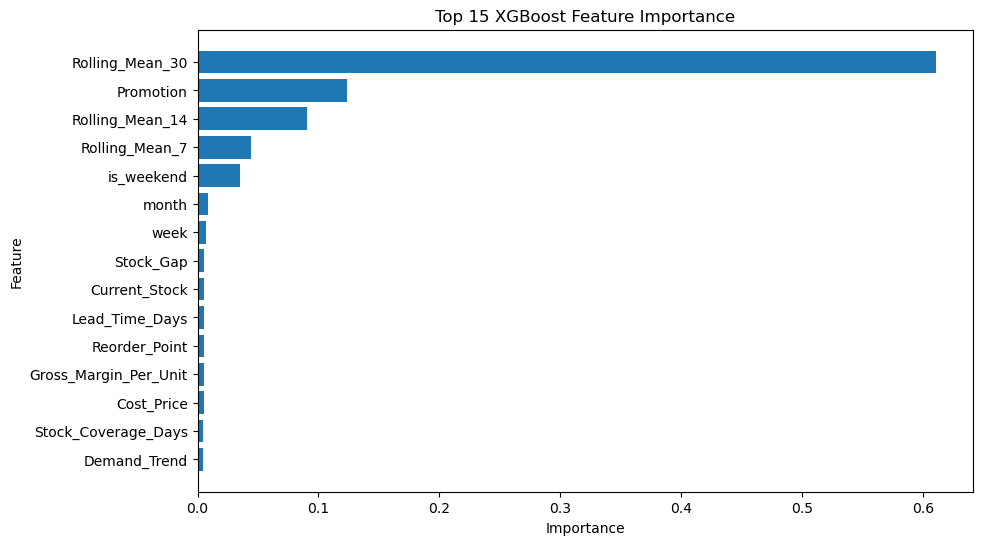

In [52]:
top_features = importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [53]:
importance.head(15)

,Feature,Importance
16,Rolling_Mean_30,0.610187
1,Promotion,0.123455
15,Rolling_Mean_14,0.090337
14,Rolling_Mean_7,0.044313
5,is_weekend,0.035363
3,month,0.008769
4,week,0.007016
23,Stock_Gap,0.005737
18,Current_Stock,0.005734
20,Lead_Time_Days,0.005562


### Demand Forecasting

In [60]:
forecast = test[
    ["Date", "SKU", "Units_Sold"]
].copy()

forecast["Predicted_Demand"] = y_pred_xgb

forecast.head(10)

,Date,SKU,Units_Sold,Predicted_Demand
366,2025-01-01,SKU001,10,12.273660
367,2025-01-02,SKU001,11,11.843105
368,2025-01-03,SKU001,9,12.144622
369,2025-01-04,SKU001,11,12.640152
370,2025-01-05,SKU001,19,14.176495
371,2025-01-06,SKU001,8,12.670626
372,2025-01-07,SKU001,24,12.327769
373,2025-01-08,SKU001,15,12.976668
374,2025-01-09,SKU001,10,12.271979
375,2025-01-10,SKU001,18,12.275347


In [61]:
forecast["Predicted_Demand"] = forecast["Predicted_Demand"].clip(
    lower=0
)

In [63]:
forecast["Predicted_Demand"] = forecast["Predicted_Demand"].round(0)

In [65]:
forecast.head(20)

,Date,SKU,Units_Sold,Predicted_Demand
366,2025-01-01,SKU001,10,12.0
367,2025-01-02,SKU001,11,12.0
368,2025-01-03,SKU001,9,12.0
369,2025-01-04,SKU001,11,13.0
370,2025-01-05,SKU001,19,14.0
371,2025-01-06,SKU001,8,13.0
372,2025-01-07,SKU001,24,12.0
373,2025-01-08,SKU001,15,13.0
374,2025-01-09,SKU001,10,12.0
375,2025-01-10,SKU001,18,12.0


In [66]:
forecast.shape

(18250, 4)

In [67]:
forecast[["Units_Sold", "Predicted_Demand"]].mean()

Units_Sold          13.984932
Predicted_Demand    14.053041
dtype: float64

In [68]:
forecast["Forecast_Error"] = (
    forecast["Units_Sold"] -
    forecast["Predicted_Demand"]
)

In [69]:
forecast["Absolute_Error"] = (
    forecast["Forecast_Error"].abs()
)

In [70]:
forecast.head(10)

,Date,SKU,Units_Sold,Predicted_Demand,Forecast_Error,Absolute_Error
366,2025-01-01,SKU001,10,12.0,-2.0,2.0
367,2025-01-02,SKU001,11,12.0,-1.0,1.0
368,2025-01-03,SKU001,9,12.0,-3.0,3.0
369,2025-01-04,SKU001,11,13.0,-2.0,2.0
370,2025-01-05,SKU001,19,14.0,5.0,5.0
371,2025-01-06,SKU001,8,13.0,-5.0,5.0
372,2025-01-07,SKU001,24,12.0,12.0,12.0
373,2025-01-08,SKU001,15,13.0,2.0,2.0
374,2025-01-09,SKU001,10,12.0,-2.0,2.0
375,2025-01-10,SKU001,18,12.0,6.0,6.0


In [71]:
sku_performance = (
    forecast
    .groupby("SKU")
    .agg(
        Actual_Demand=("Units_Sold", "sum"),
        Predicted_Demand=("Predicted_Demand", "sum"),
        MAE=("Absolute_Error", "mean")
    )
    .reset_index()
)

sku_performance.head(10)

,SKU,Actual_Demand,Predicted_Demand,MAE
0,SKU001,5267,5202.0,3.131507
1,SKU002,3759,3820.0,2.413699
2,SKU003,2117,2167.0,1.967123
3,SKU004,1675,1783.0,1.769863
4,SKU005,6066,6118.0,3.139726
5,SKU006,2415,2488.0,2.090411
6,SKU007,8962,9107.0,3.936986
7,SKU008,5964,5866.0,3.501370
8,SKU009,3909,3905.0,2.679452
9,SKU010,6174,6277.0,3.580822


In [72]:
forecast.to_csv("../data/cleaned/demand_forecast.csv",index=False)

In [73]:
forecast.head(10)

,Date,SKU,Units_Sold,Predicted_Demand,Forecast_Error,Absolute_Error
366,2025-01-01,SKU001,10,12.0,-2.0,2.0
367,2025-01-02,SKU001,11,12.0,-1.0,1.0
368,2025-01-03,SKU001,9,12.0,-3.0,3.0
369,2025-01-04,SKU001,11,13.0,-2.0,2.0
370,2025-01-05,SKU001,19,14.0,5.0,5.0
371,2025-01-06,SKU001,8,13.0,-5.0,5.0
372,2025-01-07,SKU001,24,12.0,12.0,12.0
373,2025-01-08,SKU001,15,13.0,2.0,2.0
374,2025-01-09,SKU001,10,12.0,-2.0,2.0
375,2025-01-10,SKU001,18,12.0,6.0,6.0


In [74]:
forecast.shape

(18250, 6)

### Risk Scoring

In [76]:
inventory = pd.read_csv(
    "../data/cleaned/inventory_snapshots_clean.csv"
)

inventory["Snapshot_Date"] = pd.to_datetime(
    inventory["Snapshot_Date"]
)

In [78]:
inventory_risk = inventory[
    [
        "Snapshot_Date",
        "SKU",
        "Current_Stock",
        "On_Order",
        "Lead_Time_Days",
        "Safety_Stock",
        "Reorder_Point"
    ]
].copy()

inventory_risk = inventory_risk.rename(
    columns={"Snapshot_Date": "Date"}
)

In [79]:
forecast = forecast.sort_values(
    ["SKU", "Date"]
).reset_index(drop=True)

inventory_risk = inventory_risk.sort_values(
    ["SKU", "Date"]
).reset_index(drop=True)

In [80]:
forecast_risk = pd.merge_asof(
    forecast.sort_values("Date"),
    inventory_risk.sort_values("Date"),
    on="Date",
    by="SKU",
    direction="backward"
)

In [81]:
forecast_risk.head(10)

,Date,SKU,Units_Sold,Predicted_Demand,Forecast_Error,Absolute_Error,Current_Stock,On_Order,Lead_Time_Days,Safety_Stock,Reorder_Point
0,2025-01-01,SKU001,10,12.0,-2.0,2.0,558,184,9,144,414
1,2025-01-01,SKU024,20,12.0,8.0,8.0,381,33,3,48,90
2,2025-01-01,SKU025,2,3.0,-1.0,1.0,968,203,4,162,295
3,2025-01-01,SKU047,9,13.0,-4.0,4.0,191,38,8,31,75
4,2025-01-01,SKU026,20,21.0,-1.0,1.0,201,108,14,42,128
5,2025-01-01,SKU027,19,24.0,-5.0,5.0,99,310,13,54,272
6,2025-01-01,SKU028,7,6.0,1.0,1.0,323,232,10,128,313
7,2025-01-01,SKU029,17,15.0,2.0,2.0,673,161,3,83,160
8,2025-01-01,SKU030,4,5.0,-1.0,1.0,179,46,6,23,60
9,2025-01-01,SKU031,18,18.0,0.0,0.0,98,64,7,24,68


In [82]:
forecast_risk.isnull().sum()

Date                0
SKU                 0
Units_Sold          0
Predicted_Demand    0
Forecast_Error      0
Absolute_Error      0
Current_Stock       0
On_Order            0
Lead_Time_Days      0
Safety_Stock        0
Reorder_Point       0
dtype: int64

In [83]:
forecast_risk["Available_Stock"] = (
    forecast_risk["Current_Stock"] +
    forecast_risk["On_Order"]
)

In [84]:
forecast_risk["Lead_Time_Demand"] = (
    forecast_risk["Predicted_Demand"] *
    forecast_risk["Lead_Time_Days"]
)

In [86]:
forecast_risk.head()

,Date,SKU,Units_Sold,Predicted_Demand,Forecast_Error,Absolute_Error,Current_Stock,On_Order,Lead_Time_Days,Safety_Stock,Reorder_Point,Available_Stock,Lead_Time_Demand
0,2025-01-01,SKU001,10,12.0,-2.0,2.0,558,184,9,144,414,742,108.0
1,2025-01-01,SKU024,20,12.0,8.0,8.0,381,33,3,48,90,414,36.0
2,2025-01-01,SKU025,2,3.0,-1.0,1.0,968,203,4,162,295,1171,12.0
3,2025-01-01,SKU047,9,13.0,-4.0,4.0,191,38,8,31,75,229,104.0
4,2025-01-01,SKU026,20,21.0,-1.0,1.0,201,108,14,42,128,309,294.0


In [87]:
forecast_risk["Projected_Stock"] = (
    forecast_risk["Available_Stock"] -
    forecast_risk["Lead_Time_Demand"]
)

In [88]:
forecast_risk["Stockout_Risk"] = (
    forecast_risk["Projected_Stock"] <= 0
).astype(int)

In [90]:
forecast_risk.head(10)

,Date,SKU,Units_Sold,Predicted_Demand,Forecast_Error,Absolute_Error,Current_Stock,On_Order,Lead_Time_Days,Safety_Stock,Reorder_Point,Available_Stock,Lead_Time_Demand,Projected_Stock,Stockout_Risk
0,2025-01-01,SKU001,10,12.0,-2.0,2.0,558,184,9,144,414,742,108.0,634.0,0
1,2025-01-01,SKU024,20,12.0,8.0,8.0,381,33,3,48,90,414,36.0,378.0,0
2,2025-01-01,SKU025,2,3.0,-1.0,1.0,968,203,4,162,295,1171,12.0,1159.0,0
3,2025-01-01,SKU047,9,13.0,-4.0,4.0,191,38,8,31,75,229,104.0,125.0,0
4,2025-01-01,SKU026,20,21.0,-1.0,1.0,201,108,14,42,128,309,294.0,15.0,0
5,2025-01-01,SKU027,19,24.0,-5.0,5.0,99,310,13,54,272,409,312.0,97.0,0
6,2025-01-01,SKU028,7,6.0,1.0,1.0,323,232,10,128,313,555,60.0,495.0,0
7,2025-01-01,SKU029,17,15.0,2.0,2.0,673,161,3,83,160,834,45.0,789.0,0
8,2025-01-01,SKU030,4,5.0,-1.0,1.0,179,46,6,23,60,225,30.0,195.0,0
9,2025-01-01,SKU031,18,18.0,0.0,0.0,98,64,7,24,68,162,126.0,36.0,0


In [91]:
forecast_risk.isnull().sum()

Date                0
SKU                 0
Units_Sold          0
Predicted_Demand    0
Forecast_Error      0
Absolute_Error      0
Current_Stock       0
On_Order            0
Lead_Time_Days      0
Safety_Stock        0
Reorder_Point       0
Available_Stock     0
Lead_Time_Demand    0
Projected_Stock     0
Stockout_Risk       0
dtype: int64

### risk scoring

In [92]:
forecast_risk["Risk_Level"] = np.select(
    [
        forecast_risk["Projected_Stock"] <= 0,
        forecast_risk["Projected_Stock"] < forecast_risk["Safety_Stock"]
    ],
    [
        "High",
        "Medium"
    ],
    default="Low"
)

In [93]:
forecast_risk[
    [
        "SKU",
        "Predicted_Demand",
        "Current_Stock",
        "On_Order",
        "Lead_Time_Days",
        "Safety_Stock",
        "Projected_Stock",
        "Stockout_Risk",
        "Risk_Level"
    ]
].head(20)

,SKU,Predicted_Demand,Current_Stock,On_Order,Lead_Time_Days,Safety_Stock,Projected_Stock,Stockout_Risk,Risk_Level
0,SKU001,12.0,558,184,9,144,634.0,0,Low
1,SKU024,12.0,381,33,3,48,378.0,0,Low
2,SKU025,3.0,968,203,4,162,1159.0,0,Low
3,SKU047,13.0,191,38,8,31,125.0,0,Low
4,SKU026,21.0,201,108,14,42,15.0,0,Medium
5,SKU027,24.0,99,310,13,54,97.0,0,Low
6,SKU028,6.0,323,232,10,128,495.0,0,Low
7,SKU029,15.0,673,161,3,83,789.0,0,Low
8,SKU030,5.0,179,46,6,23,195.0,0,Low
9,SKU031,18.0,98,64,7,24,36.0,0,Low


In [94]:
forecast_risk["Risk_Level"].value_counts()

Risk_Level
Low       16001
High       1564
Medium      685
Name: count, dtype: int64

In [95]:
high_risk = forecast_risk[
    forecast_risk["Risk_Level"] == "High"
]

high_risk[
    [
        "Date",
        "SKU",
        "Predicted_Demand",
        "Current_Stock",
        "On_Order",
        "Lead_Time_Days",
        "Safety_Stock",
        "Projected_Stock"
    ]
].head(20)

,Date,SKU,Predicted_Demand,Current_Stock,On_Order,Lead_Time_Days,Safety_Stock,Projected_Stock
13,2025-01-01,SKU034,19.0,41,88,12,35,-99.0
31,2025-01-01,SKU010,17.0,37,0,12,18,-167.0
33,2025-01-01,SKU040,15.0,84,25,10,31,-41.0
34,2025-01-01,SKU012,24.0,60,18,4,15,-18.0
48,2025-01-01,SKU042,21.0,65,24,12,29,-163.0
52,2025-01-02,SKU034,19.0,41,88,12,35,-99.0
59,2025-01-02,SKU042,21.0,65,24,12,29,-163.0
88,2025-01-02,SKU010,16.0,37,0,12,18,-155.0
89,2025-01-02,SKU040,15.0,84,25,10,31,-41.0
91,2025-01-02,SKU012,24.0,60,18,4,15,-18.0


In [96]:
forecast_risk["Risk_Level"].value_counts()

Risk_Level
Low       16001
High       1564
Medium      685
Name: count, dtype: int64

In [97]:
forecast_risk[
    forecast_risk["Risk_Level"] == "High"
].shape

(1564, 16)

In [98]:
forecast_risk[
    forecast_risk["Risk_Level"] == "High"
][
    [
        "Date",
        "SKU",
        "Predicted_Demand",
        "Current_Stock",
        "On_Order",
        "Lead_Time_Days",
        "Safety_Stock",
        "Projected_Stock"
    ]
].head(20)

,Date,SKU,Predicted_Demand,Current_Stock,On_Order,Lead_Time_Days,Safety_Stock,Projected_Stock
13,2025-01-01,SKU034,19.0,41,88,12,35,-99.0
31,2025-01-01,SKU010,17.0,37,0,12,18,-167.0
33,2025-01-01,SKU040,15.0,84,25,10,31,-41.0
34,2025-01-01,SKU012,24.0,60,18,4,15,-18.0
48,2025-01-01,SKU042,21.0,65,24,12,29,-163.0
52,2025-01-02,SKU034,19.0,41,88,12,35,-99.0
59,2025-01-02,SKU042,21.0,65,24,12,29,-163.0
88,2025-01-02,SKU010,16.0,37,0,12,18,-155.0
89,2025-01-02,SKU040,15.0,84,25,10,31,-41.0
91,2025-01-02,SKU012,24.0,60,18,4,15,-18.0


In [99]:
forecast_risk[
    forecast_risk["Risk_Level"] == "High"
]["SKU"].nunique()

21

In [100]:
forecast_risk[
    forecast_risk["Risk_Level"] == "High"
]["SKU"].value_counts().head(10)

SKU
SKU012    270
SKU010    257
SKU026    226
SKU031    173
SKU040    137
SKU034    113
SKU048     63
SKU042     59
SKU047     43
SKU017     39
Name: count, dtype: int64

In [101]:
forecast_risk.to_csv("../data/cleaned/inventory_risk.csv",index=False)